In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

In [2]:
df = pd.read_csv("HR Analytics.csv")
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


# Data Inspection And Cleaning

In [3]:
df.head()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
df.shape

(1470, 35)

In [5]:
df.columns = df.columns.str.replace(r'(?<!^)(?=[A-Z])', '_', regex=True).str.lower()

In [6]:
df.columns

Index(['age', 'attrition', 'business_travel', 'daily_rate', 'department',
       'distance_from_home', 'education', 'education_field', 'employee_count',
       'employee_number', 'environment_satisfaction', 'gender', 'hourly_rate',
       'job_involvement', 'job_level', 'job_role', 'job_satisfaction',
       'marital_status', 'monthly_income', 'monthly_rate',
       'num_companies_worked', 'over18', 'over_time', 'percent_salary_hike',
       'performance_rating', 'relationship_satisfaction', 'standard_hours',
       'stock_option_level', 'total_working_years', 'training_times_last_year',
       'work_life_balance', 'years_at_company', 'years_in_current_role',
       'years_since_last_promotion', 'years_with_curr_manager'],
      dtype='object')

In [7]:
df = df.drop(columns=["employee_count","employee_number","over18","standard_hours"])

In [8]:
df.head(1)

,age,attrition,business_travel,daily_rate,department,distance_from_home,education,education_field,environment_satisfaction,gender,...,performance_rating,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5


In [9]:
df.isnull().sum().sum()

np.int64(0)

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df["age_group"] = pd.cut(df["age"],bins=[0, 25, 35, 45, 55, 100],labels=["Under 25", "25-34", "35-44", "45-54", "55+"])

In [12]:
df["salary_band"] = pd.cut(df["monthly_income"],bins=[0, 3000, 6000, 10000, float("inf")],labels=["Low", "Medium", "High", "Very High"])

In [13]:
df["tenure_band"] = pd.cut(df["years_at_company"],bins=[-1, 1, 3, 5, 10, float("inf")],labels=["0-1", "2-3", "4-5", "6-10", "10+"])

In [14]:
df["promotion_gap_band"] = pd.cut(df["years_since_last_promotion"],bins=[-1, 2, 5, float("inf")],labels=["0-2", "3-5", "5+"])

In [15]:
df["distance_band"] = pd.cut(df["distance_from_home"],bins=[-1, 5, 15, float("inf")],labels=["Near", "Moderate", "Far"])

In [16]:
df["experience_band"] = pd.cut(df["total_working_years"],bins=[-1,5,10,20,100],labels=["0-5","6-11","12-20","20+"])

In [17]:
df["job_level_band"] = pd.cut(df["job_level"], bins=[0,1,2,3,4,5], labels=["Entry","Junior","Mid","Senior","Executive"])

In [18]:
df["work_life_balance_band"] = pd.cut(df["work_life_balance"], bins=[0,1,2,3,4], labels=["Bad","Good","Better","Best"])

In [19]:
df["job_satisfaction_band"] = pd.cut(df["job_satisfaction"], bins=[0,1,2,3,4], labels=["Low Satisfaction","Moderate Satisfaction","High Satisfaction","Very High Satisfaction"])

In [20]:
df.head()

,age,attrition,business_travel,daily_rate,department,distance_from_home,education,education_field,environment_satisfaction,gender,...,years_with_curr_manager,age_group,salary_band,tenure_band,promotion_gap_band,distance_band,experience_band,job_level_band,work_life_balance_band,job_satisfaction_band
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,5,35-44,Medium,6-10,0-2,Near,6-11,Junior,Bad,Very High Satisfaction
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,7,45-54,Medium,6-10,0-2,Moderate,6-11,Junior,Better,Moderate Satisfaction
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,0,35-44,Low,0-1,0-2,Near,6-11,Entry,Better,High Satisfaction
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,0,25-34,Low,6-10,3-5,Near,6-11,Entry,Better,High Satisfaction
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,2,25-34,Medium,2-3,0-2,Near,6-11,Entry,Better,Moderate Satisfaction


# Exploratory Data Analysis

In [21]:
df.shape

(1470, 40)

In [22]:
#ATTRITION COUNT
df["attrition"].value_counts()

attrition
No     1233
Yes     237
Name: count, dtype: int64

In [23]:
df["over_time"].value_counts()

over_time
No     1054
Yes     416
Name: count, dtype: int64

In [24]:
# ATTRITION PERCENTAGE
df["attrition"].value_counts(normalize=True)*100

attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

In [25]:
avg_dept_salary=df.groupby("department")["monthly_income"].mean().sort_values()
avg_dept_salary

department
Research & Development    6281.252862
Human Resources           6654.507937
Sales                     6959.172646
Name: monthly_income, dtype: float64

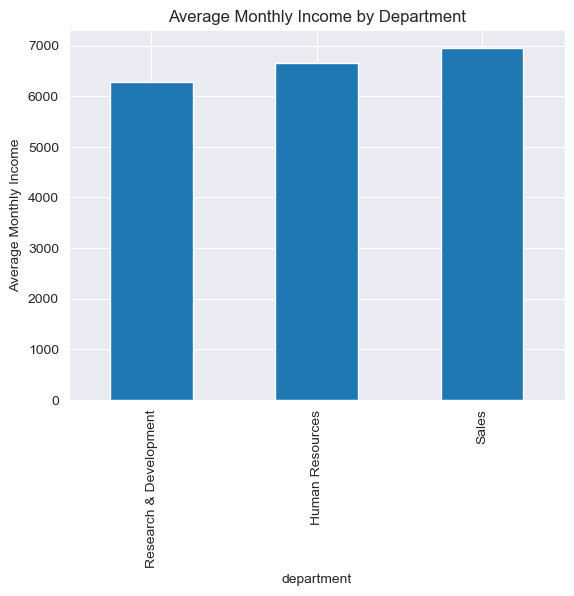

In [26]:
#df.groupby("department")["monthly_income"].mean().sort_values().plot(kind="bar")
avg_dept_salary.plot(kind="bar")
plt.title("Average Monthly Income by Department")
plt.ylabel("Average Monthly Income")
plt.show()

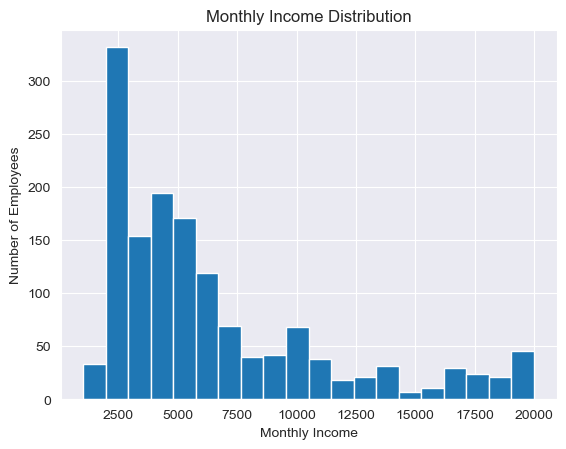

In [27]:
#salary distibution
plt.hist(df["monthly_income"], bins=20)

plt.title("Monthly Income Distribution")
plt.xlabel("Monthly Income")
plt.ylabel("Number of Employees")
plt.show()

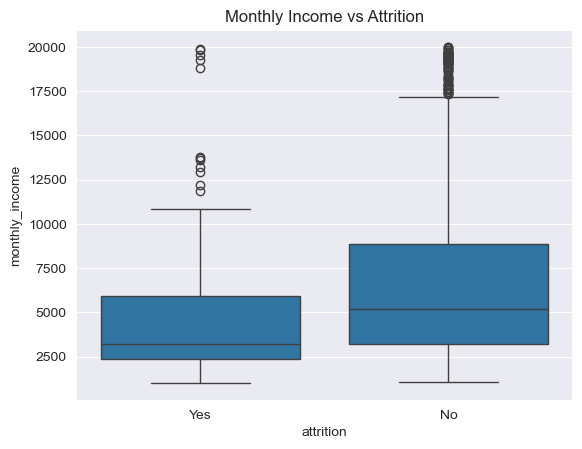

In [28]:
#salary vs attrition
sns.boxplot(data=df,x="attrition",y="monthly_income")
plt.title("Monthly Income vs Attrition")
plt.show()

In [29]:
avg_sal_job_role=df.groupby("job_role")["monthly_income"].mean().sort_values(ascending=False)
avg_sal_job_role

job_role
Manager                      17181.676471
Research Director            16033.550000
Healthcare Representative     7528.763359
Manufacturing Director        7295.137931
Sales Executive               6924.279141
Human Resources               4235.750000
Research Scientist            3239.972603
Laboratory Technician         3237.169884
Sales Representative          2626.000000
Name: monthly_income, dtype: float64

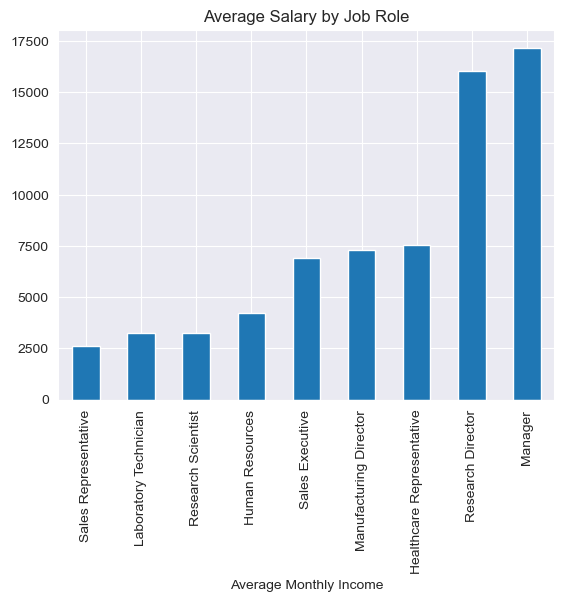

In [30]:
df.groupby("job_role")["monthly_income"].mean().sort_values().plot(kind="bar")
plt.xticks(rotation=90)
plt.title("Average Salary by Job Role")
plt.xlabel("Average Monthly Income")
plt.show()

In [31]:
avg_sal_job_level=df.groupby("job_level_band")["monthly_income"].mean().sort_values(ascending=False)
avg_sal_job_level

C:\Users\ayush\AppData\Local\Temp\ipykernel_20944\1494142675.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_sal_job_level=df.groupby("job_level_band")["monthly_income"].mean().sort_values(ascending=False)


job_level_band
Executive    19191.826087
Senior       15503.783019
Mid           9817.252294
Junior        5502.277154
Entry         2786.915285
Name: monthly_income, dtype: float64

In [32]:
#overtime employees average salary
df.groupby("over_time")["monthly_income"].mean()

over_time
No     6484.926945
Yes    6548.548077
Name: monthly_income, dtype: float64

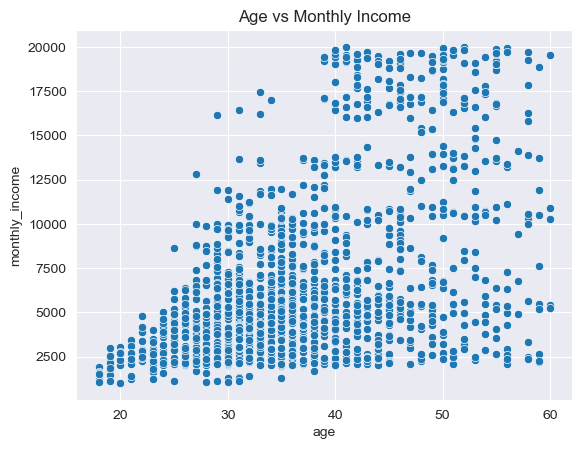

In [33]:
#age vs income pattern
sns.scatterplot(data=df, x="age", y="monthly_income")
plt.title("Age vs Monthly Income")
plt.show()

In [34]:
#years since promotion avg monthly salary
df.groupby("promotion_gap_band")["monthly_income"].mean()

C:\Users\ayush\AppData\Local\Temp\ipykernel_20944\2852209923.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("promotion_gap_band")["monthly_income"].mean()


promotion_gap_band
0-2    5709.434822
3-5    8025.696203
5+     9432.553488
Name: monthly_income, dtype: float64

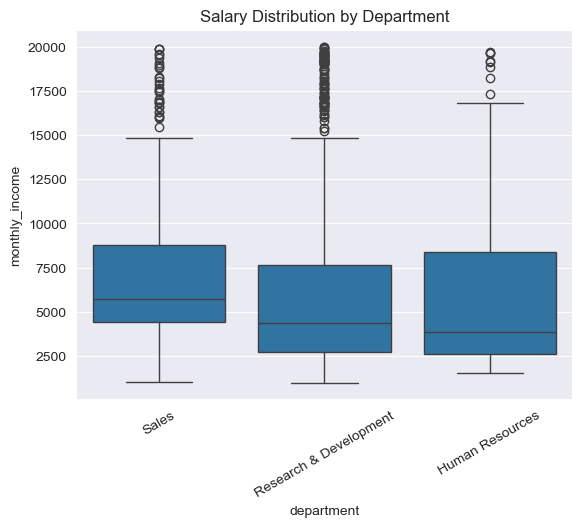

In [35]:
#department vs salary boxplot
sns.boxplot(data=df,x="department",y="monthly_income")

plt.title("Salary Distribution by Department")
plt.xticks(rotation=30)
plt.show()

In [36]:
# number of people who left vs people who stayed
department_attrition = pd.crosstab(df["department"],df["attrition"],normalize="index")*100

department_attrition

attrition,No,Yes
department,,
Human Resources,80.952381,19.047619
Research & Development,86.160250,13.839750
Sales,79.372197,20.627803


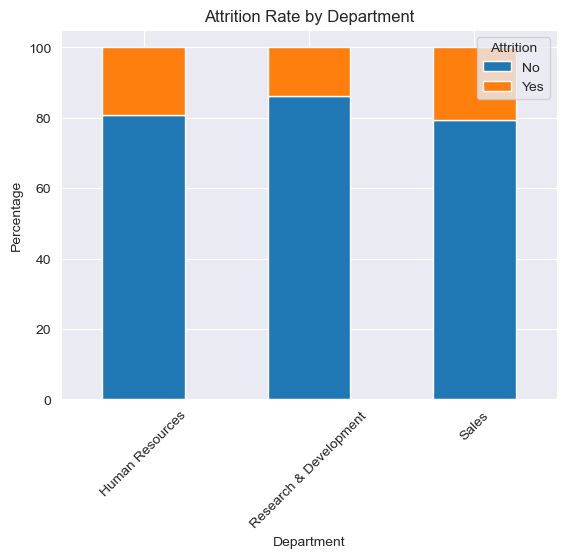

In [37]:
department_attrition.plot(kind="bar", stacked=True)
plt.xticks(rotation=45)

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Percentage")
plt.legend(title="Attrition")
plt.show()

In [38]:
# job-wise attrition
role_attrition = pd.crosstab(df["job_role"],df["attrition"],normalize="index")*100
role_attrition

attrition,No,Yes
job_role,,
Healthcare Representative,93.129771,6.870229
Human Resources,76.923077,23.076923
Laboratory Technician,76.061776,23.938224
Manager,95.098039,4.901961
Manufacturing Director,93.103448,6.896552
Research Director,97.500000,2.500000
Research Scientist,83.904110,16.095890
Sales Executive,82.515337,17.484663
Sales Representative,60.240964,39.759036


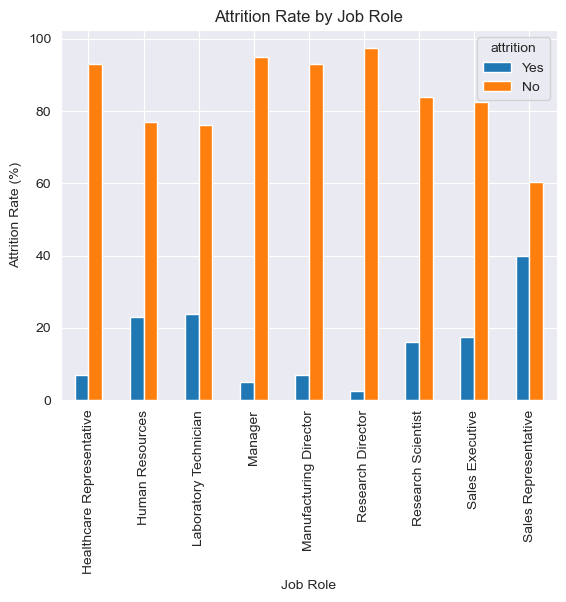

In [39]:
role_attrition[["Yes","No"]].plot(kind="bar")

plt.title("Attrition Rate by Job Role")
plt.xlabel("Job Role")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=90)
plt.show()

In [27]:
pd.crosstab(df["department"], df["job_role"])

job_role,Healthcare Representative,Human Resources,Laboratory Technician,Manager,Manufacturing Director,Research Director,Research Scientist,Sales Executive,Sales Representative
department,,,,,,,,,
Human Resources,0,52,0,11,0,0,0,0,0
Research & Development,131,0,259,54,145,80,292,0,0
Sales,0,0,0,37,0,0,0,326,83


In [40]:
# age group vs attrition
age_attrition = pd.crosstab(df["age_group"],df["attrition"],normalize="index")*100
age_attrition

attrition,No,Yes
age_group,,
Under 25,64.227642,35.772358
25-34,80.858086,19.141914
35-44,90.811966,9.188034
45-54,88.495575,11.504425
55+,82.978723,17.021277


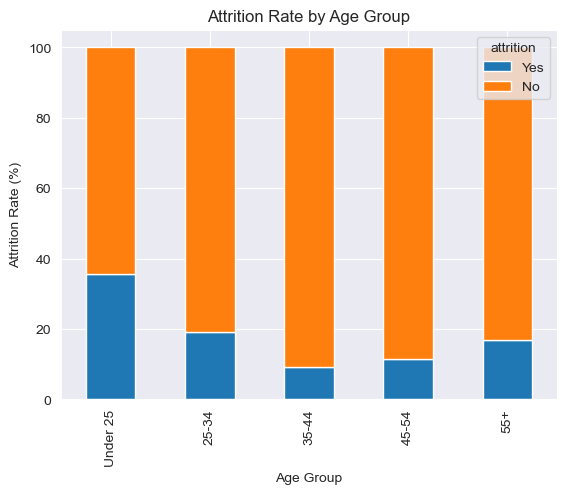

In [41]:
age_attrition[["Yes","No"]].plot(kind="bar",stacked=True)

plt.title("Attrition Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Attrition Rate (%)")
plt.show()

In [28]:
# salary band vs attrition
salary_attrition = pd.crosstab(df["salary_band"],df["attrition"],normalize="index")*100
salary_attrition

attrition,No,Yes
salary_band,,
Low,71.392405,28.607595
Medium,87.283237,12.716763
High,88.000000,12.000000
Very High,91.103203,8.896797


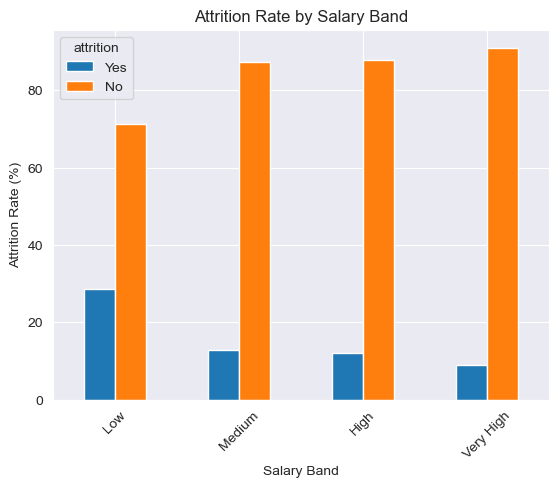

In [43]:
salary_attrition[["Yes","No"]].plot(kind="bar")
plt.xticks(rotation=45)
plt.title("Attrition Rate by Salary Band")
plt.xlabel("Salary Band")
plt.ylabel("Attrition Rate (%)")
plt.show()

In [44]:
df['job_satisfaction']

0       4
1       2
2       3
3       3
4       2
       ..
1465    4
1466    1
1467    2
1468    2
1469    3
Name: job_satisfaction, Length: 1470, dtype: int64

In [45]:
#tenure vs attrition
tenure_attrition = pd.crosstab(df["tenure_band"],df["attrition"],normalize="index")*100
tenure_attrition

attrition,No,Yes
tenure_band,,
0-1,65.116279,34.883721
2-3,81.568627,18.431373
4-5,86.928105,13.071895
6-10,87.723214,12.276786
10+,91.869919,8.130081


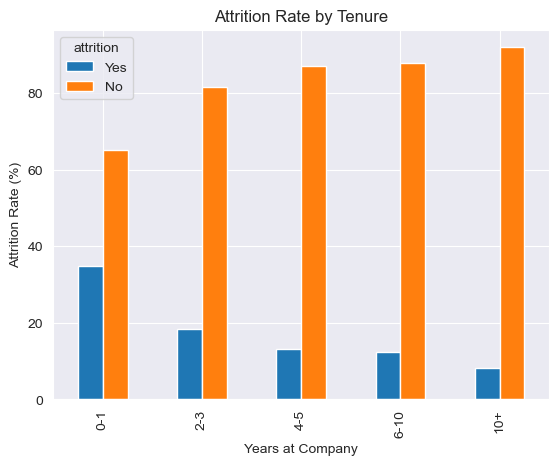

In [46]:
tenure_attrition[["Yes","No"]].plot(kind="bar")

plt.title("Attrition Rate by Tenure")
plt.xlabel("Years at Company")
plt.ylabel("Attrition Rate (%)")
plt.show()

In [47]:
#overtime vs attrition
overtime_attrition = pd.crosstab(df["over_time"],df["attrition"],normalize="index")*100
overtime_attrition

attrition,No,Yes
over_time,,
No,89.563567,10.436433
Yes,69.471154,30.528846


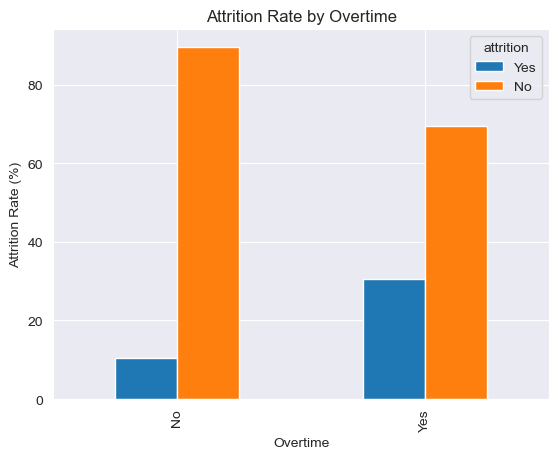

In [48]:
overtime_attrition[["Yes","No"]].plot(kind="bar")

plt.title("Attrition Rate by Overtime")
plt.xlabel("Overtime")
plt.ylabel("Attrition Rate (%)")
plt.show()

In [49]:
#promotion gap vs attrition
promotion_attrition = pd.crosstab(df["promotion_gap_band"],df["attrition"],normalize="index")*100
promotion_attrition

attrition,No,Yes
promotion_gap_band,,
0-2,83.044667,16.955333
3-5,89.873418,10.126582
5+,83.720930,16.279070


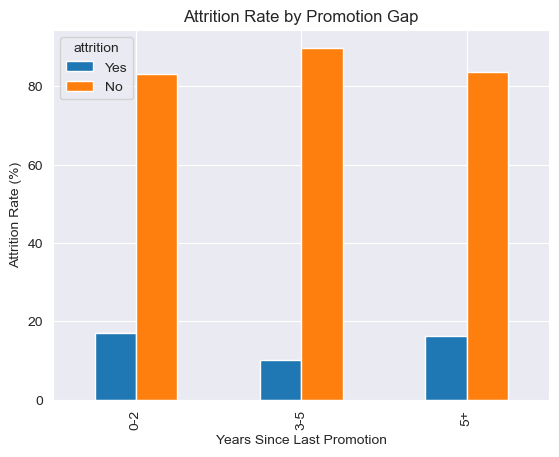

In [50]:
promotion_attrition[["Yes","No"]].plot(kind="bar")

plt.title("Attrition Rate by Promotion Gap")
plt.xlabel("Years Since Last Promotion")
plt.ylabel("Attrition Rate (%)")
plt.show()

In [51]:
#distance from home vs attrition
distance_attrition = pd.crosstab(df["distance_band"],df["attrition"],normalize="index")*100
distance_attrition

attrition,No,Yes
distance_band,,
Near,86.234177,13.765823
Moderate,83.889980,16.110020
Far,79.331307,20.668693


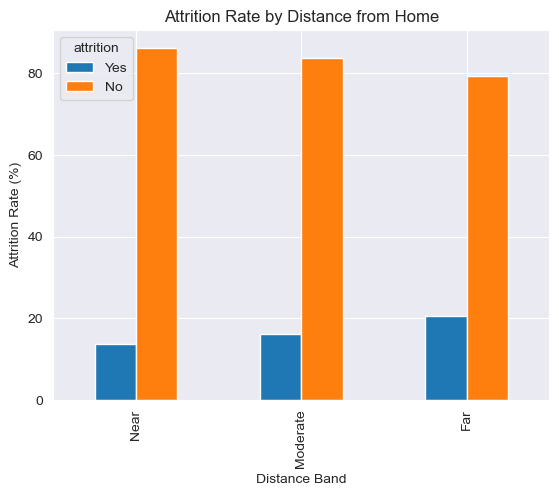

In [52]:
distance_attrition[["Yes","No"]].plot(kind="bar")

plt.title("Attrition Rate by Distance from Home")
plt.xlabel("Distance Band")
plt.ylabel("Attrition Rate (%)")
plt.show()

In [53]:
#gender vs attrition
gender_attrition = pd.crosstab(df["gender"],df["attrition"],normalize="index")*100
gender_attrition

attrition,No,Yes
gender,,
Female,85.204082,14.795918
Male,82.993197,17.006803


In [54]:
#job level vs attrition
job_level_attrition = pd.crosstab(df["job_level_band"],df["attrition"],normalize="index")*100
job_level_attrition

attrition,No,Yes
job_level_band,,
Entry,73.664825,26.335175
Junior,90.262172,9.737828
Mid,85.321101,14.678899
Senior,95.283019,4.716981
Executive,92.753623,7.246377


# Correlation Analysis


In [55]:
df["attrition_flag"] = df["attrition"].map({"No": 0, "Yes": 1})

In [56]:
attrition_corr = df.select_dtypes("number").corr()["attrition_flag"].sort_values(ascending=False)
attrition_corr

attrition_flag                1.000000
distance_from_home            0.077924
num_companies_worked          0.043494
monthly_rate                  0.015170
performance_rating            0.002889
hourly_rate                  -0.006846
percent_salary_hike          -0.013478
education                    -0.031373
years_since_last_promotion   -0.033019
relationship_satisfaction    -0.045872
daily_rate                   -0.056652
training_times_last_year     -0.059478
work_life_balance            -0.063939
environment_satisfaction     -0.103369
job_satisfaction             -0.103481
job_involvement              -0.130016
years_at_company             -0.134392
stock_option_level           -0.137145
years_with_curr_manager      -0.156199
age                          -0.159205
monthly_income               -0.159840
years_in_current_role        -0.160545
job_level                    -0.169105
total_working_years          -0.171063
Name: attrition_flag, dtype: float64

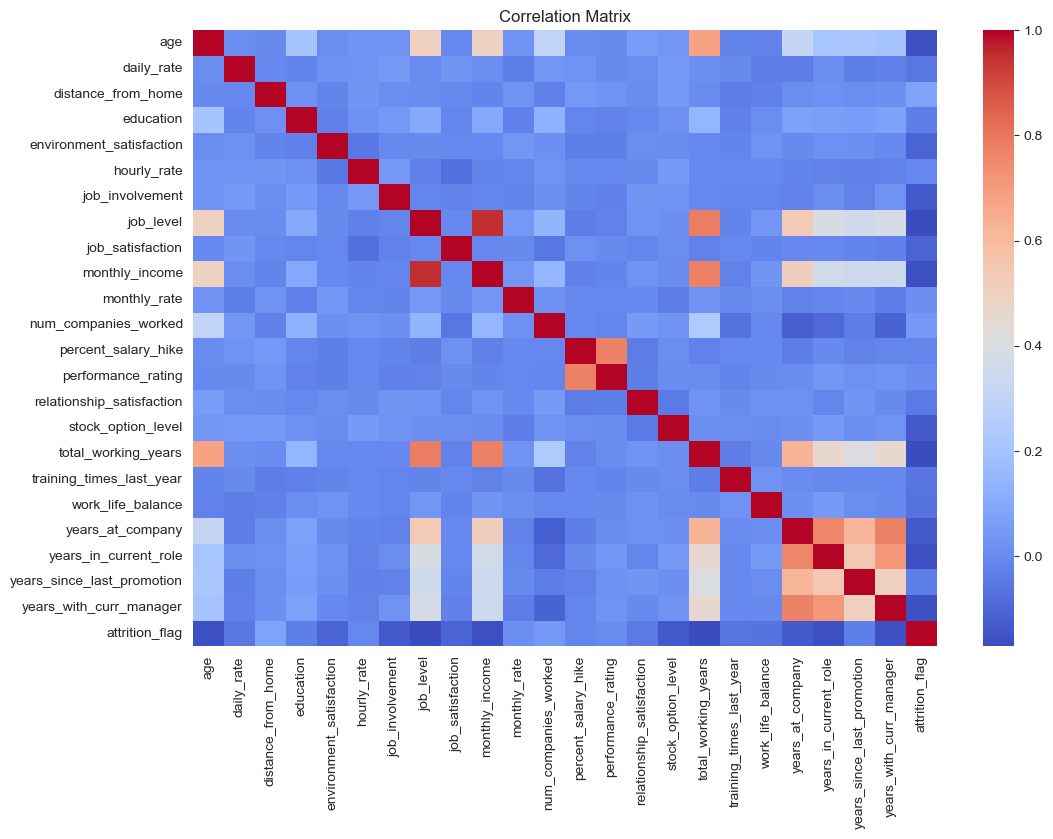

In [57]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes("number").corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# Risk Segmentation

In [58]:
df["risk_score"] =(df.apply(lambda x: 1 if x["over_time"] == "Yes" else 0, axis=1)+ 
     df.apply(lambda x: 1 if x["distance_band"] == "Far" else 0, axis=1)+
     df.apply(lambda x: 1 if x["promotion_gap_band"] == "5+ Years" else 0, axis=1)+
     df.apply(lambda x: 1 if x["work_life_balance_band"] in ["Bad", "Good"] else 0, axis=1)+
     df.apply(lambda x: 1 if x["job_satisfaction_band"] in ["Low Satisfaction", "Moderate Satisfaction"] else 0, axis=1)+
     df.apply(lambda x: 1 if x["years_with_curr_manager"] <= 2 else 0, axis=1)+
     df.apply(lambda x: 1 if x["salary_band"] == "Low" else 0, axis=1)+
     df.apply(lambda x: 1 if x["age_group"] == "Under 25" else 0, axis=1)+
     df.apply(lambda x: 1 if x["job_role"] == "Sales Representative" else 0, axis=1)
)
df["risk_score"]

0       2
1       1
2       3
3       3
4       2
       ..
1465    2
1466    1
1467    2
1468    2
1469    1
Name: risk_score, Length: 1470, dtype: int64

In [59]:
df["risk_score"].value_counts()

risk_score
2    422
1    388
3    285
0    162
4    146
5     54
6     10
7      3
Name: count, dtype: int64

In [60]:
df["risk_level"] = df["risk_score"].apply(
    lambda x: "Low" if x <= 3 else ("Medium" if x <=4  else "High"))

In [61]:
df["risk_level"].value_counts()

risk_level
Low       1257
Medium     146
High        67
Name: count, dtype: int64

In [62]:
risk_attrition = df.groupby("risk_level", observed=False)["attrition_flag"].mean() * 100
risk_attrition

risk_level
High      61.194030
Low       11.455847
Medium    35.616438
Name: attrition_flag, dtype: float64

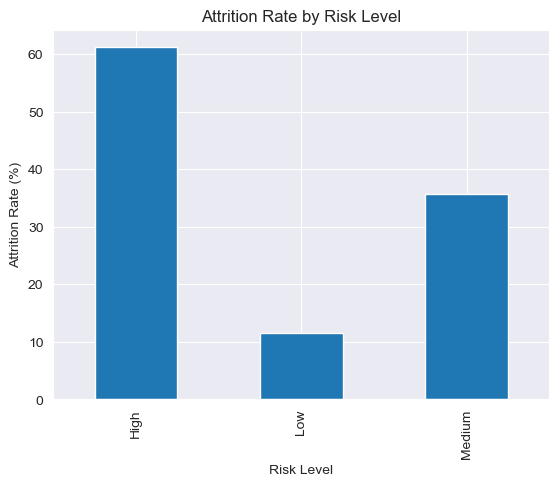

In [63]:
risk_attrition.plot(kind="bar")
plt.title("Attrition Rate by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Attrition Rate (%)")
plt.show()

## Key Findings

### 1. Overall Attrition
- The overall employee attrition rate is **16.12%**, with **237 out of 1,470 employees** leaving the organization.

### 2. Overtime is a Major Attrition Factor
- Employees working overtime have an attrition rate of **30.53%**, compared with **10.44%** for employees who do not work overtime.
- This indicates a strong association between overtime and employee attrition.

### 3. Salary and Attrition
- Employees in the **Low salary band** have the highest attrition rate of **28.61%**.
- Attrition decreases to **12.72%** in the Medium band and **8.90%** in the Very High band.
- Low-salary employees have more than **3×** the attrition rate of Very High salary employees.

### 4. Early Tenure is a High-Risk Period
- Employees with **0–1 years** at the company have an attrition rate of **34.88%**.
- This falls to **18.43%** for employees with 2–3 years and **8.13%** for employees with 10+ years.
- Early-stage employee retention should therefore be a key HR focus.

### 5. Younger Employees Show Higher Attrition
- Employees **under 25** have the highest attrition rate at **35.77%**.
- Attrition falls to **19.14%** for employees aged 25–34 and **9.19%** for employees aged 35–44.

### 6. Job Role Has a Strong Difference in Attrition
- **Sales Representatives** have the highest attrition rate at **39.76%**.
- Laboratory Technicians have **23.94%** and HR employees have **23.08%**.
- In comparison, Managers have only **4.90%** and Research Directors **2.50%**.

### 7. Distance from Home Shows a Gradual Increase in Attrition
- Employees living **Near** the workplace have an attrition rate of **13.77%**.
- Attrition increases to **16.11%** for employees living at a Moderate distance.
- Employees in the **Far** category have the highest rate at **20.67%**.
- Distance has a positive but relatively weak correlation with attrition, so it should be considered a supporting factor rather than a standalone driver.

### 8. Company Tenure is Negatively Associated with Attrition
- Attrition is substantially higher among employees with shorter company tenure.
- The attrition rate is **34.88%** for employees with 0–1 years at the company, compared with only **8.13%** for employees with 10+ years.
- This suggests that retention efforts are particularly important during the early employment period.

### 9. Attrition is Higher Among Lower-Income Employees
- The monthly income distribution shows that employees who left generally had lower salaries than employees who stayed.
- The median monthly income is approximately **₹3,200** for employees who left compared with approximately **₹5,200** for employees who stayed.
- This indicates a notable association between compensation and attrition.

### 10. Attrition Differs Across Departments
- Employee compensation also varies across departments.
- Sales has the highest median monthly income at approximately **₹5,700**, followed by R&D at **₹4,400**, while HR has the lowest at approximately **₹3,900**.
- Department-level compensation differences should therefore be considered while evaluating retention.

### 11. Promotion Gap Does Not Show a Clear Linear Relationship
- Employees with a **0–2 year** promotion gap have **16.95%** attrition.
- The rate falls to **10.13%** for 3–5 years and rises again to **16.28%** for 5+ years.
- Therefore, promotion delay alone does not show a consistent linear relationship with attrition in this dataset.

### 12. Experience is Negatively Associated with Attrition
- `total_working_years` has a correlation of approximately **-0.17** with attrition.
- This indicates that employees with greater overall experience tend to show lower attrition, although the relationship is not strong.

### 13. Job Level and Income are Negatively Associated with Attrition
- `job_level` has a correlation of approximately **-0.17**, while `monthly_income` has a correlation of approximately **-0.16** with attrition.
- Higher job levels and higher income are therefore associated with lower attrition in the dataset.

### 14. Performance Rating is Not a Major Attrition Indicator
- `performance_rating` has an almost zero correlation with attrition (**~0.003**).
- This suggests that employee performance rating alone does not meaningfully distinguish employees who leave from those who stay.

### 15. Risk Factors Can Be Combined for Employee Risk Segmentation
- Multiple factors such as **overtime, low work-life balance, low job satisfaction, greater distance from work, short tenure, and short manager tenure** can be combined into an employee risk score.
- The resulting risk segmentation can help HR identify groups that may require stronger retention interventions.

## Business Recommendations

### 1. Focus on New Employees
- Employees with 0–1 years of tenure have **34.88% attrition**.
- HR should improve the onboarding process and regularly check with new employees to understand their problems early.

### 2. Reduce Excessive Overtime
- Employees doing overtime have **30.53% attrition**, compared with **10.44%** for others.
- The company should review workload and staffing in teams where overtime is high.

### 3. Review Low-Salary Employees
- The Low salary group has **28.61% attrition**, while the Very High salary group has only **8.90%**.
- HR should review salaries and ensure that lower-paid employees are competitively compensated.

### 4. Focus on High-Attrition Job Roles
- Sales Representatives have the highest attrition at **39.76%**.
- HR should identify why employees are leaving these roles and review factors such as workload, targets, incentives, and career growth.

### 5. Improve Retention of Younger Employees
- Employees under 25 have **35.77% attrition**.
- The company should provide better career growth, mentoring, and learning opportunities for younger employees.

### 6. Improve Employee Satisfaction
- Employees with lower job satisfaction and work-life balance appear more likely to leave.
- HR should regularly collect employee feedback and take action on workload, work environment, and employee concerns.

### 7. Use the Risk Score to Prioritize Employees
- The risk score combines multiple factors such as overtime, satisfaction, distance, tenure, and manager tenure.
- HR can use it to identify **high-risk employee groups** and focus retention efforts where they are most needed.

### 8. Consider Commute-Related Issues
- Employees living Far from the workplace have **20.67% attrition**, compared with **13.77%** for employees living Near.
- The company can investigate commute problems and consider suitable flexible-work or location-related support.

## Conclusion

- The analysis shows that employee attrition is associated with multiple factors such as **overtime, salary level, tenure, age, job role, job satisfaction, and distance from work**.

- The highest attrition was observed among **employees with 0–1 years of tenure (34.88%)**, **employees under 25 (35.77%)**, and **Sales Representatives (39.76%)**.

- **Overtime and lower salary levels** also showed a strong association with higher attrition, with overtime employees having **30.53% attrition** and the Low salary group having **28.61% attrition**.

- Based on these findings, the company can focus on **new-employee retention, reducing excessive overtime, reviewing compensation, improving employee satisfaction, and addressing high-attrition job roles**.

- The risk segmentation can further help HR **identify employees with multiple risk factors and prioritize retention efforts**.

- Overall, this analysis provides a **data-driven view of employee attrition** and can help HR make better decisions to improve employee retention.

In [74]:
pip install sqlalchemy psycopg2-binary

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [75]:
from sqlalchemy import create_engine

username = "postgres"
password = "Ayush30"
host = "localhost"
port = 5432
database = "attrition"
engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

df.to_sql("hr_employee_attrition",engine,if_exists="replace",index=False)
print("HR data successfully loaded")


HR data successfully loaded
